## Speedtest import workflow
### Follow steps to import global data, extract AUS, check unique (line count) and save locally and figshare
Created: Richard Ferrers, 18/11/22 CC_BY

In [1]:
# https://github.com/teamookla/ookla-open-data/blob/master/tutorials/aggregate_by_county_py.ipynb
# Speedtest Jupyter Notebook - demonstration code
# Pandas cheatsheet - https://pandas.pydata.org/Pandas_Cheat_Sheet.pdf
# https://colab.research.google.com/drivespeedtest/.../geopandas.ipynb
%matplotlib inline
# !pip install geopandas
# !pip install shapely
# !pip install rtree
# !apt-get install -y libspatialindex-dev
from datetime import datetime

import geopandas as gp
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from shapely.geometry import Point
# from adjustText import adjust_text - this library not loaded

/Users/rf/anaconda3/lib/python3.7/site-packages/geopandas/_compat.py:115: UserWarning: The Shapely GEOS version (3.8.0-CAPI-1.13.1 ) is incompatible with the GEOS version PyGEOS was compiled with (3.10.3-CAPI-1.16.1). Conversions between both will be slow.
  shapely_geos_version, geos_capi_version_string


In [2]:
def quarter_start(year: int, q: int) -> datetime:
    if not 1 <= q <= 4:
        raise ValueError("Quarter must be within [1, 2, 3, 4]")

    month = [1, 4, 7, 10]
    return datetime(year, month[q - 1], 1)


def get_tile_url(service_type: str, year: int, q: int) -> str:
    dt = quarter_start(year, q)

    base_url = "https://ookla-open-data.s3-us-west-2.amazonaws.com/shapefiles/performance"
    url = f"{base_url}/type%3D{service_type}/year%3D{dt:%Y}/quarter%3D{q}/{dt:%Y-%m-%d}_performance_fixed_tiles.zip"
    return url

#speedtest import data from aws

In [14]:
tile_url = get_tile_url("fixed", 2022, 3)
tile_url
#let's load Q2, Q3 22 data

'https://ookla-open-data.s3-us-west-2.amazonaws.com/shapefiles/performance/type%3Dfixed/year%3D2022/quarter%3D3/2022-07-01_performance_fixed_tiles.zip'

In [15]:
print (datetime.now())
# tells me how long takes to import data

2022-11-18 12:41:57.779951


In [16]:
tiles = gp.read_file(tile_url)
# load times - 30 mins (Sun pm), 8 mins (Mon am), 12mins (Sun pm), 11mins (Sat pm)
# load time -  12 mins (Fri am), 14 mins (Fri am)
# load time - 6 mins, (Fri pm),  6 mins (Fri pm) (now at 100Mbps, was 50Mbps)
# load time - x mins (Fri pm) (on 100Mbps NBN)

In [17]:
print (datetime.now())

2022-11-18 12:49:31.971654


In [18]:
len(tiles)
# Q1 21 - 6.3M lines
# Q2 21 - 6.7M lines (global)
# Q3 21 - 6.9M lines
# Q4 21 - 6.7M lines (AU 86115 lines)
# Q1 22 - 6.7M lines (AU 88182 lines)
# Q2 22 - 6.6M lines (AU 86704 lines)
# Q3 22 - 6.609M lines (AU 83458 lines)

# how to save/load
#au_tiles.to_file("speedtest-AUS-Q221.geojson", driver='GeoJSON')
#working - reloaded successfully
# au2_tiles = gp.read_file("speedtest.geojson")

6609476

In [19]:
au_tiles = tiles.cx[113.338953:153.569469 ,	-43.634597:-10.668186]
#LAX = tiles.cx[-118:-120, 33:35]
len(au_tiles)
# processing World data to Australia subset by bounding box
# source of Bounding Box - World data set
# processing time - 5 mins, 9 mins

83458

In [20]:
au_tiles.to_file("speedtest-AUS-Q322.geojson", driver='GeoJSON')

#write to disk
# then load to figshare: CC-BY-NC https://doi.org/10.6084/m9.figshare.13370504 (Currently at.v22)

/Users/rf/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:1: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  """Entry point for launching an IPython kernel.


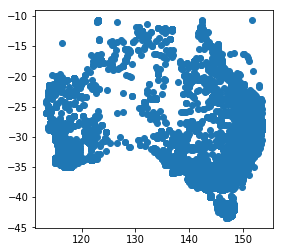

In [21]:
au_tiles.centroid.plot()
# Visual data inspection
# Q222 - looks like some E.Timor data or Coral Sea (New Guinea?)

In [22]:
au_tiles['avg_d_kbps'].mean()
# Q2 21 - 52314
# Q3 21 - 54854
# Q4 21 - 57645
# Q1 22 - 56873
# Q2 22 - 58442
# Q3 22 - 61658


61658.798149967646

In [23]:
au_tiles.describe()

,avg_d_kbps,avg_u_kbps,avg_lat_ms,tests,devices
count,83458.000000,83458.000000,83458.000000,83458.000000,83458.000000
mean,61658.798150,15676.615040,44.479031,18.653071,5.801253
std,47725.967486,16947.986979,112.755346,34.385658,9.573512
min,4.000000,2.000000,0.000000,1.000000,1.000000
25%,33200.250000,7870.000000,10.000000,2.000000,1.000000
50%,50849.500000,14968.500000,15.000000,6.000000,2.000000
75%,76539.750000,18692.000000,35.000000,21.000000,7.000000
max,925932.000000,627223.000000,2890.000000,1144.000000,495.000000


In [ ]:
# to do -